In [199]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pymutspec.draw import plot_mutspec192
from pymutspec.draw import plot_mutspec12
from pymutspec.annotation import CodonAnnotation
from pymutspec.annotation import rev_comp


### First of all merge the taxa and 12-comp mutspec

12 comp mutspec df here:


In [179]:
mtsp12 = pd.read_csv('spectra12.csv')
mtsp12 = mtsp12.fillna(0)
mtsp12 = mtsp12.melt(id_vars='gene__species', value_vars=mtsp12.columns[1:])
mtsp12['Species'] = mtsp12['gene__species'].apply(lambda x: x.rsplit('__')[1])
mtsp12['Gene'] = mtsp12['gene__species'].apply(lambda x: x.rsplit('__')[0])
mtsp12 = mtsp12.drop(['gene__species'], axis=1)
mtsp12 = mtsp12.rename(columns={'value': 'MutSpec', 'variable': 'Mut'})
mtsp12.head()

,Mut,MutSpec,Species,Gene
0,A>C,0.000000,Acanthurus_nigricans,A6
1,A>C,0.033073,Acanthurus_triostegus,A6
2,A>C,0.000000,Adelomyia_melanogenys,A6
3,A>C,0.026959,Agkistrodon_contortrix,A6
4,A>C,0.018371,Agkistrodon_piscivorus,A6


taxa data is here:

In [186]:
taxa = pd.read_csv('info.csv')
taxa = taxa.drop(['acc', 'gene'], axis=1)
taxa['Class']= taxa['taxa'].apply(lambda x: x.rsplit(';')[1].rsplit('_')[0]) # take class from taxa column
taxa = taxa.drop(['taxa'], axis=1).drop_duplicates()
taxa['species'] = taxa['species'].str.replace(' ', '_')
taxa.head()

,species,Class
0,Branchiostoma_belcheri,Leptocardii
1,Branchiostoma_floridae,Leptocardii
2,Branchiostoma_lanceolatum,Leptocardii
3,Lampetra_fluviatilis,Hyperoartia
4,Lampetra_planeri,Hyperoartia


merge mutspec and taxa

In [225]:
mut_spec_with_taxa = pd.merge(left=mtsp12, right=taxa, left_on='Species', right_on='species', how='left')
mut_spec_with_taxa = mut_spec_with_taxa.drop('species', axis=1)
mut_spec_with_taxa.head()

,Mut,MutSpec,Species,Gene,Class
0,A>C,0.000000,Acanthurus_nigricans,A6,Actinopteri
1,A>C,0.033073,Acanthurus_triostegus,A6,Actinopteri
2,A>C,0.000000,Adelomyia_melanogenys,A6,Aves
3,A>C,0.026959,Agkistrodon_contortrix,A6,Lepidosauria
4,A>C,0.018371,Agkistrodon_piscivorus,A6,Lepidosauria


Size after merging is the same

In [226]:
print(f'Length of mutspec is {len(mtsp12)}, and lenght after merging with taxa is {len(mut_spec_with_taxa)}')

Length of mutspec is 105780, and lenght after merging with taxa is 105780


Take only Mammalia class for the TBSS analysis

In [250]:
mammalia_mutspec = mut_spec_with_taxa.loc[mut_spec_with_taxa['Class'] == 'Mammalia']
mammalia_mutspec.head()

,Mut,MutSpec,Species,Gene,Class
23,A>C,0.0,Aotus_azarai,A6,Mammalia
24,A>C,0.0,Apodemus_agrarius,A6,Mammalia
25,A>C,0.0,Arctocephalus_forsteri,A6,Mammalia
31,A>C,0.0,Balaena_mysticetus,A6,Mammalia
32,A>C,0.0,Balaenoptera_musculus,A6,Mammalia


How much species left for CytB species, the nummber are greater then previous one

In [233]:
print(f'The number of mammalian species for Cytb gene is: {len(mammalia_mutspec[mammalia_mutspec.Gene == "Cytb"]) / 12}')

The number of mammalian species for Cytb gene is: 1097.0


CHANGE ANNOTATION TO HEAVY STRAND except ND6

In [244]:
def getrevers(mut):
    translator = str.maketrans("ACGT", "TGCA")
    new_mut = mut.translate(translator)
    return new_mut

In [251]:
mammalia_mutspec['Mut'] = mammalia_mutspec.apply(lambda x: getrevers(x.Mut) if x.Gene != 'ND6' else(x.Mut), axis=1)

/var/folders/zp/hykk29rd2lndslkkjgkzfb640000gn/T/ipykernel_37892/215573261.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mammalia_mutspec['Mut'] = mammalia_mutspec.apply(lambda x: getrevers(x.Mut) if x.Gene != 'ND6' else(x.Mut), axis=1)


In [252]:
mammalia_mutspec.head()

,Mut,MutSpec,Species,Gene,Class
23,T>G,0.0,Aotus_azarai,A6,Mammalia
24,T>G,0.0,Apodemus_agrarius,A6,Mammalia
25,T>G,0.0,Arctocephalus_forsteri,A6,Mammalia
31,T>G,0.0,Balaena_mysticetus,A6,Mammalia
32,T>G,0.0,Balaenoptera_musculus,A6,Mammalia


Plot 12 comp mutspec for CytB mammals

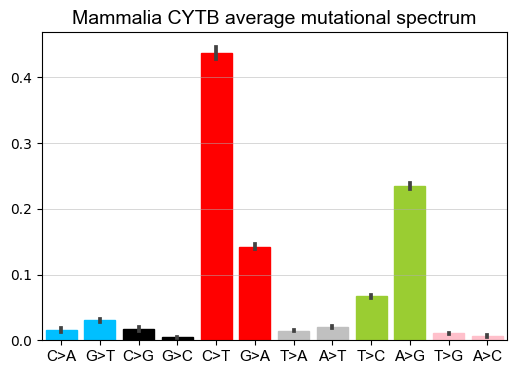

In [254]:
ax = plot_mutspec12(
    mammalia_mutspec[mammalia_mutspec.Gene == 'Cytb'].groupby(["Species", "Mut"]).MutSpec.sum().reset_index(), 
    fontname="Arial", ticksize=11, title="Mammalia CYTB average mutational spectrum")

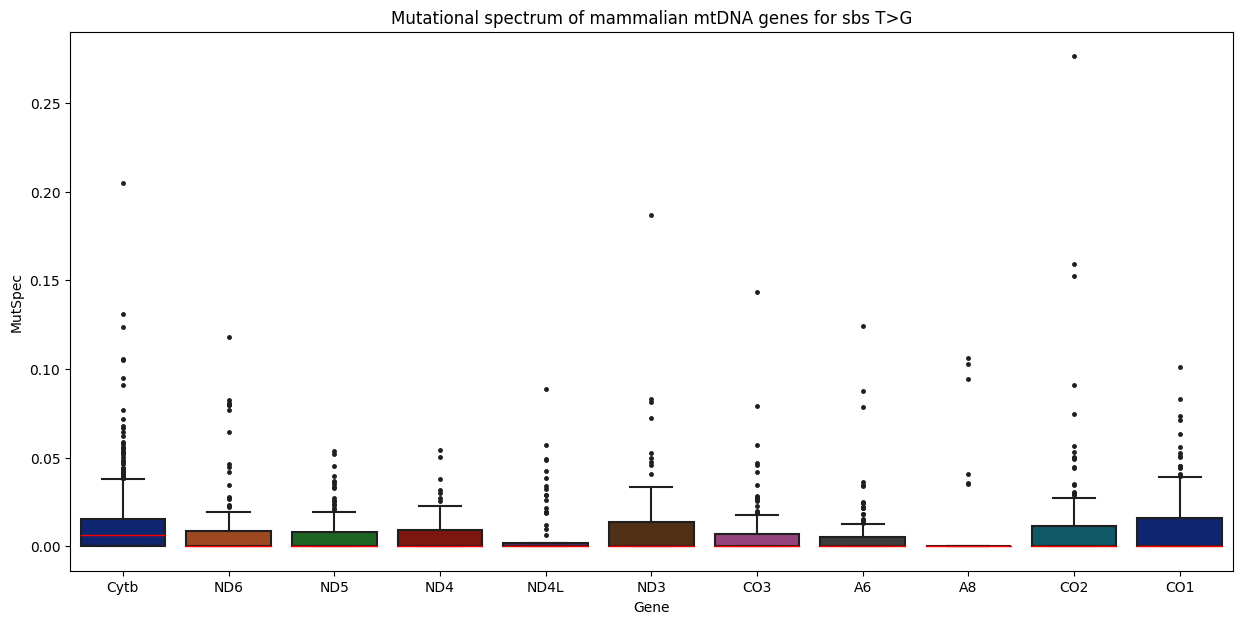

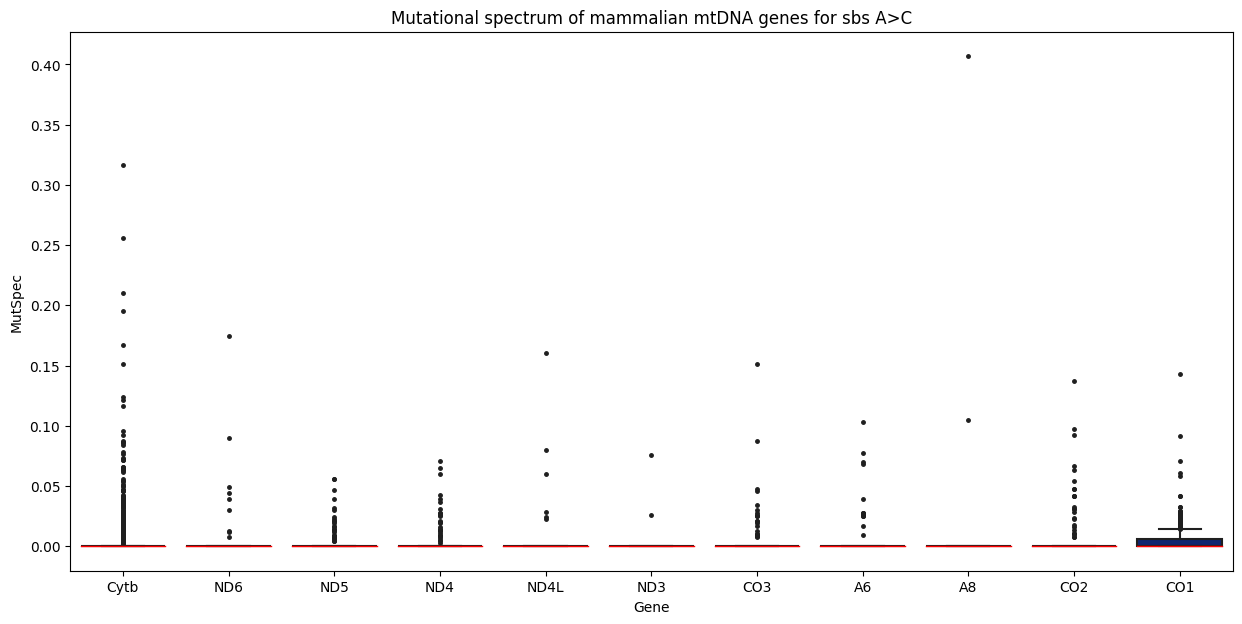

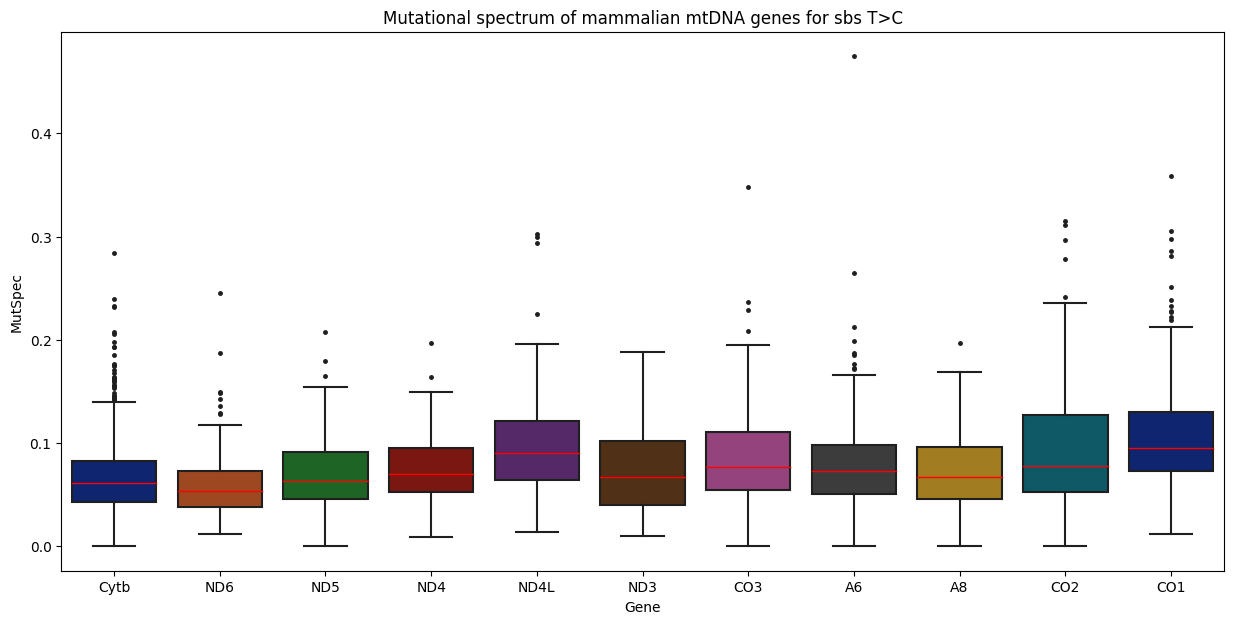

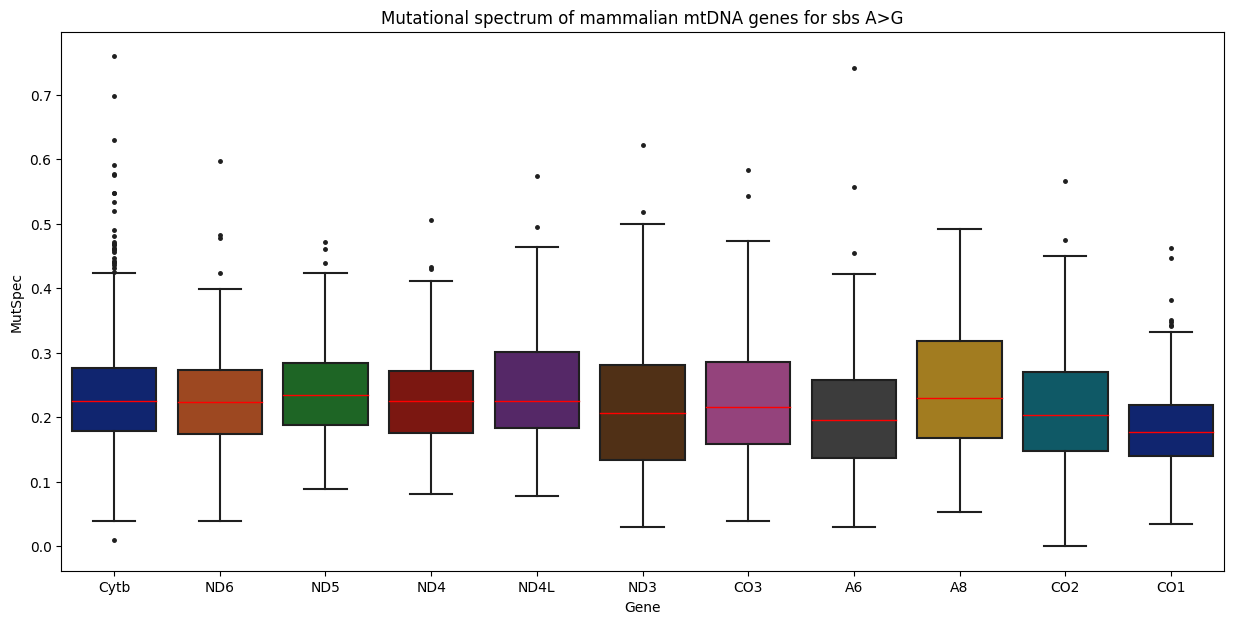

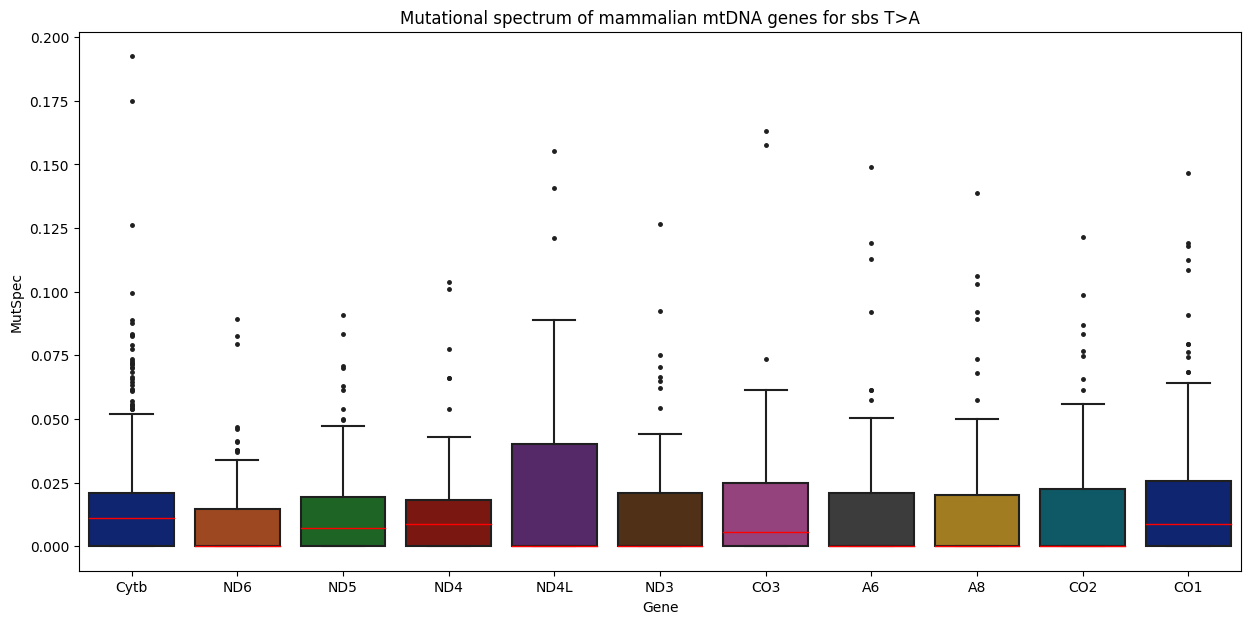

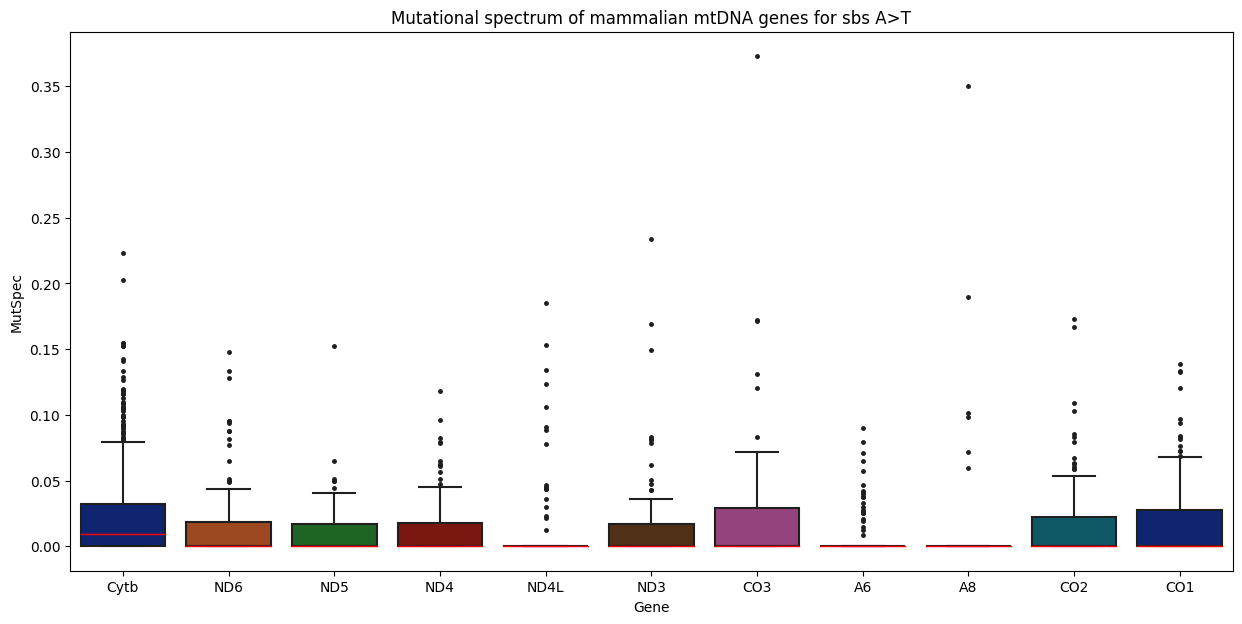

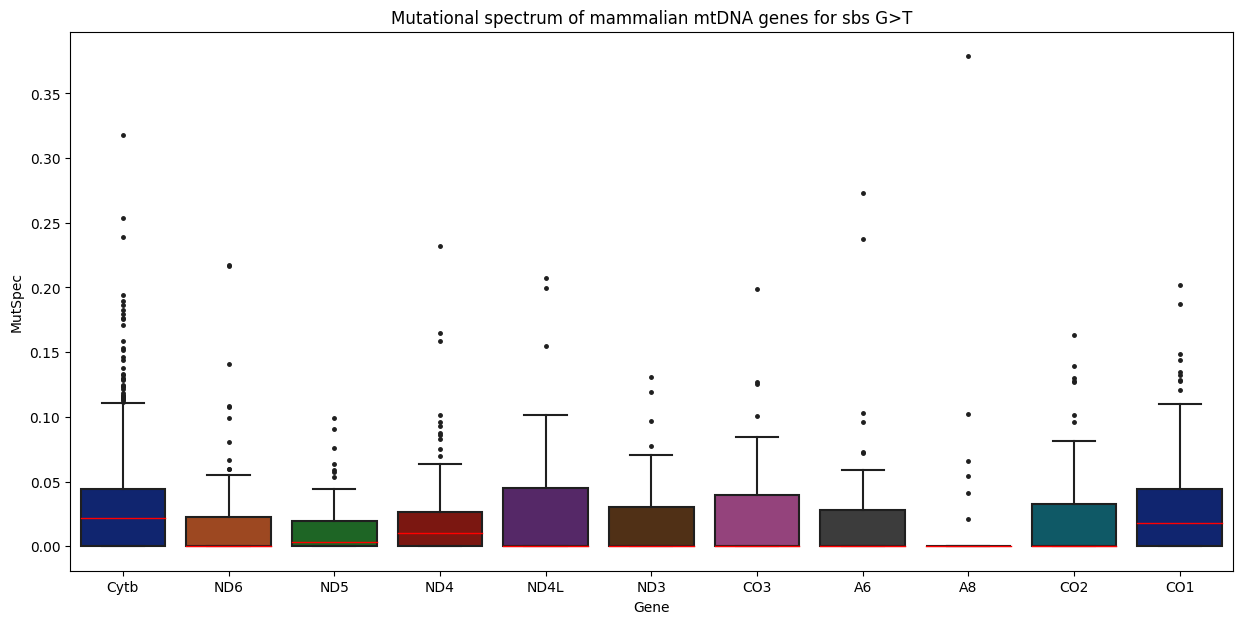

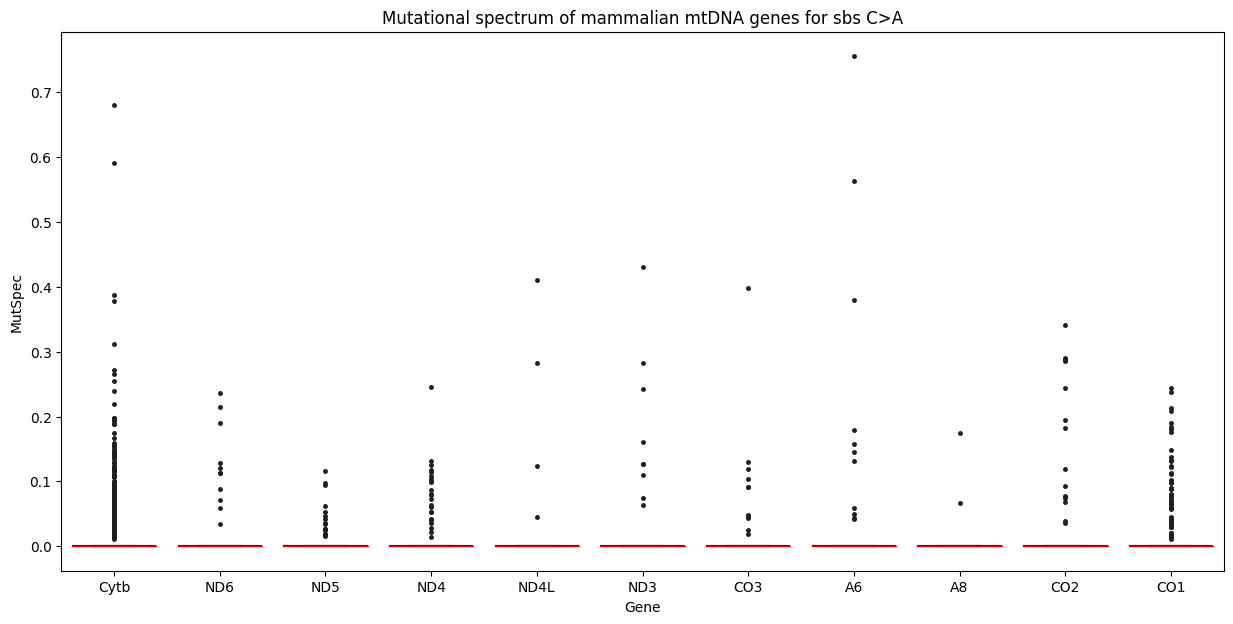

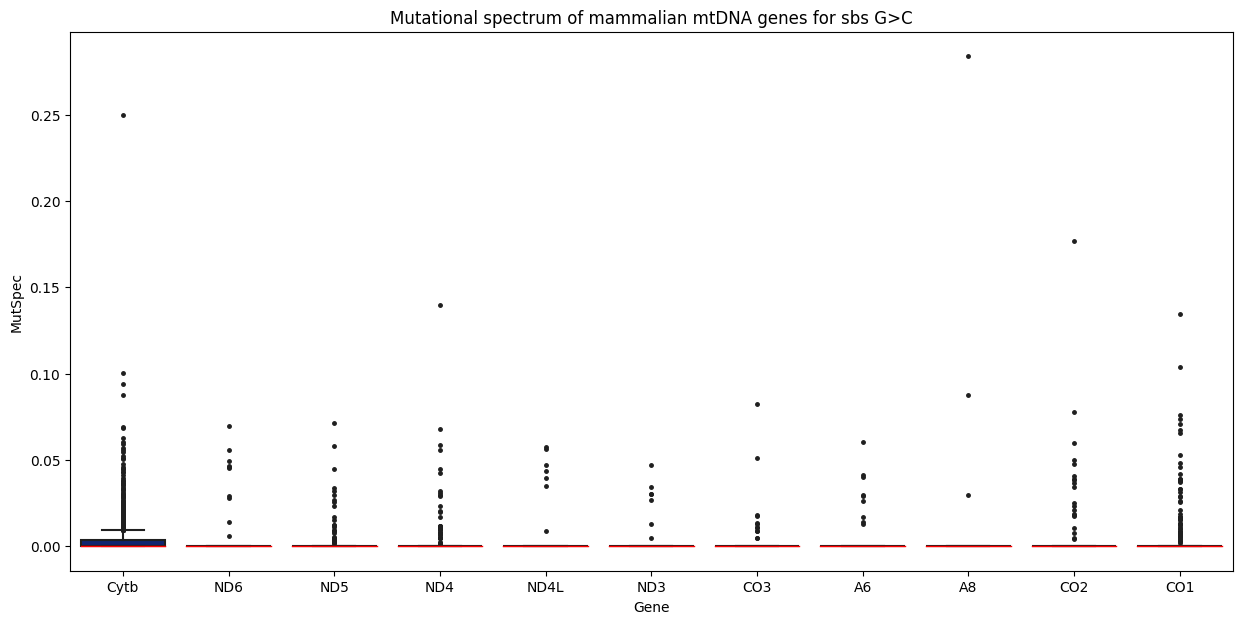

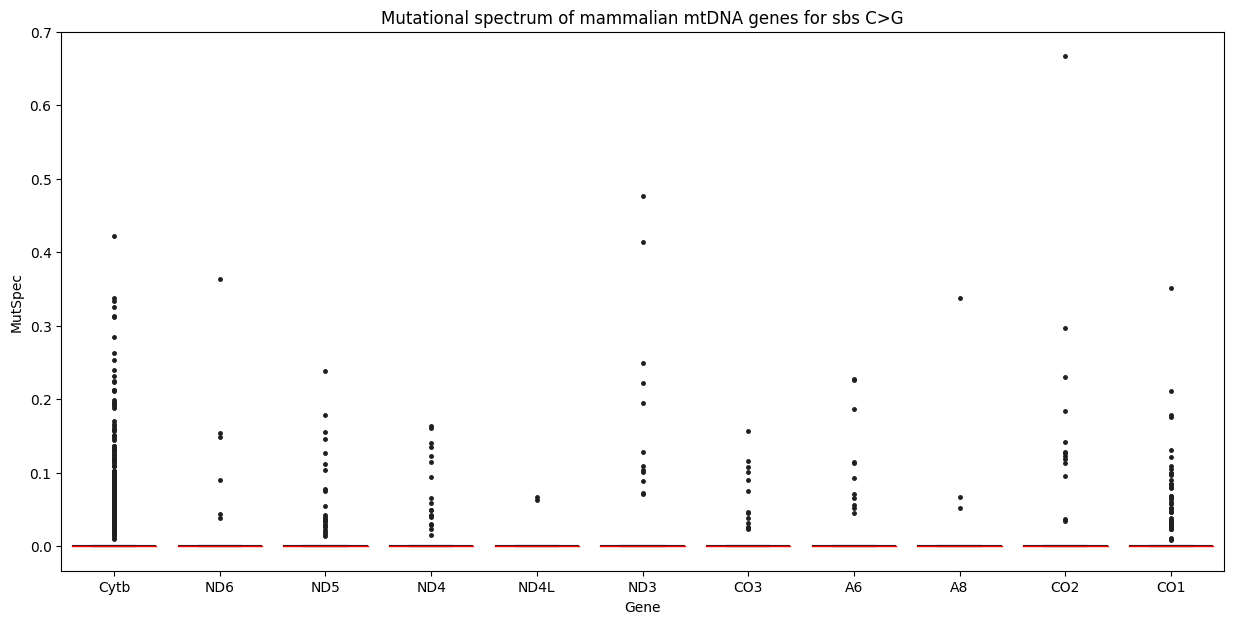

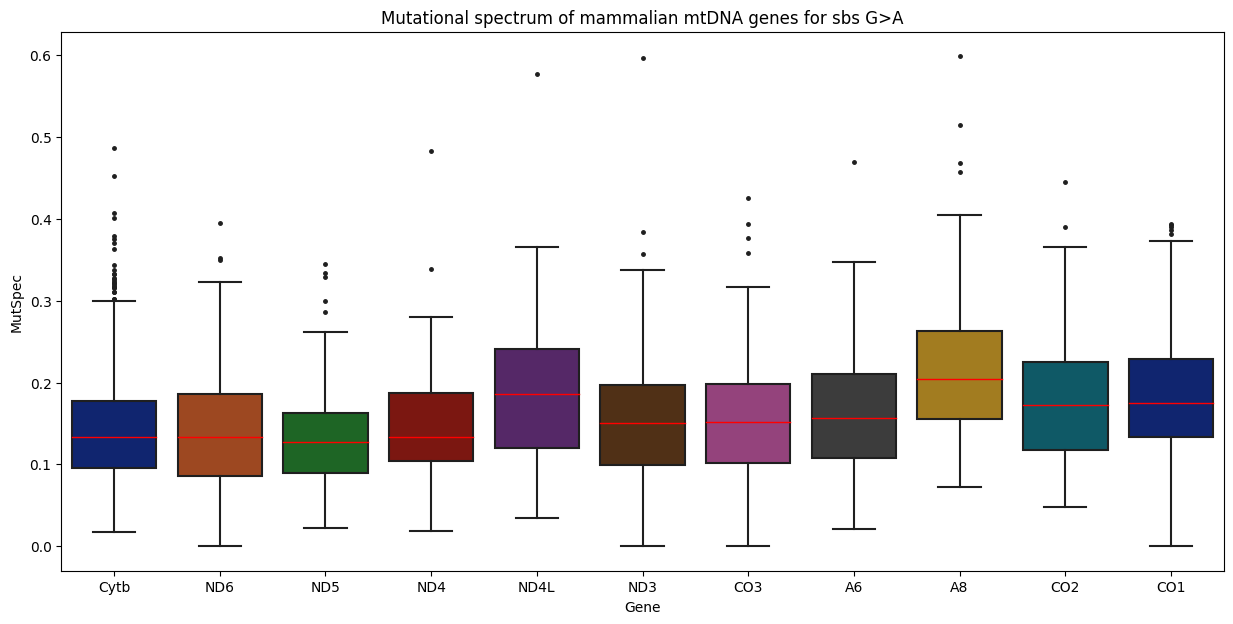

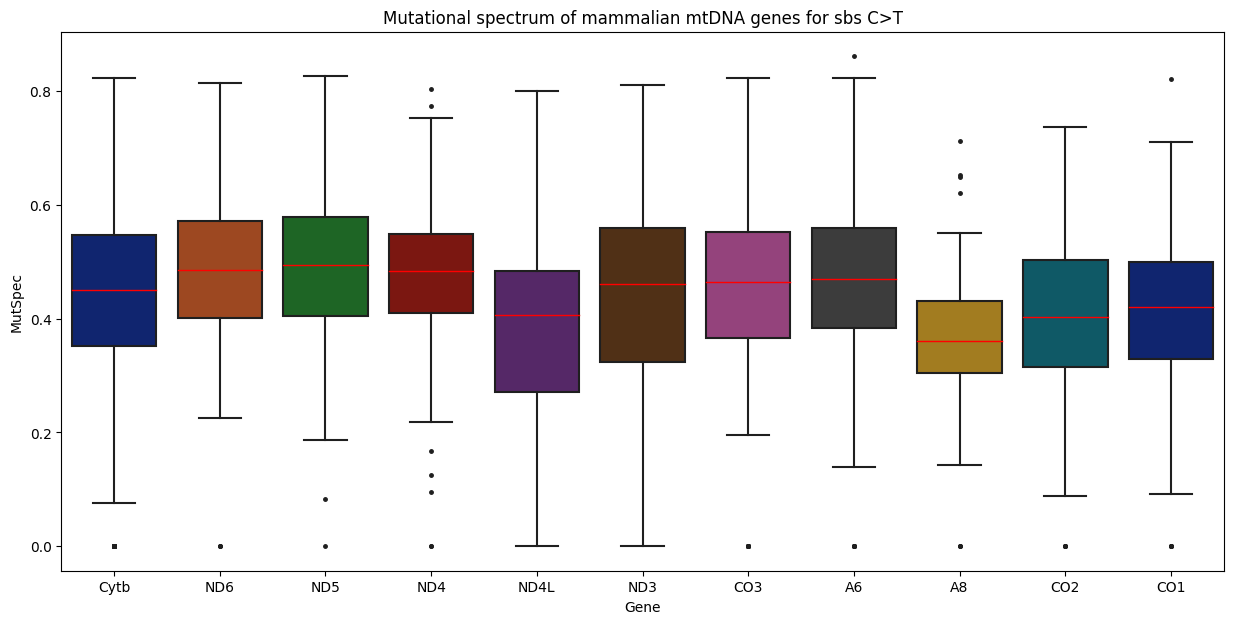

In [258]:
for subs in list(mammalia_mutspec.Mut.drop_duplicates()):
    plt.figure(figsize=(15,7))
    ax = sns.boxplot(data = mammalia_mutspec[mammalia_mutspec.Mut == subs], x='Gene', y='MutSpec', notch=False, palette='dark', medianprops={"color": "r", "linewidth": 1}, flierprops={"marker": "."},
                order=['Cytb', 'ND6', 'ND5', 'ND4', 'ND4L', 'ND3', 'CO3', 'A6', 'A8', 'CO2', 'CO1'])
    ax.set_title(f'Mutational spectrum of mammalian mtDNA genes for sbs {subs}')
    #plt.ylim(0, 0.1)